## Homework for stimulus optimization

## Probing a compact model --- what are its stimulus preferences?

in this module:
- You'll work with a compact DNN trained to predict a V4 neuron.
- You'll try three different ways to probe the stimulus preference of the compact model.

Your goal is to gain some insight into the visual features a real V4 neuron cares about.


Note: We provide a "compact_modelXX.h5" assigned to you. Coordinate with your classmates to ensure each student has a different compact model for ID XX.

Note: It is fine to use AI/LLMs for help, but this applies only to this coding exercise. First try each code part without LLM help.

**NOTE:** Upload "compact_modelXX.h5" and "images_5k.zip" into your workspace.

In [ ]:
# imports, load model and images
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from io import BytesIO

import tensorflow as tf
import tf_keras as keras
from keras import backend as Kback
tf.compat.v1.disable_eager_execution()

# NOTE: Make sure to upload these two files to your runtime workspace.

# load model
model = keras.models.load_model('/content/compact_modelXX.h5')  # compact model, replace XX with ID (0 to 30)

# load zip of images
archive = zipfile.ZipFile('/content/images_5k.zip', 'r')  #  images in zipped memory


Instructions for updating:
Colocations handled automatically by placer.


# Plot kernel weights

Plot the kernel weights for each convolutional layer (and the last readout layer)

Note the architecture of a compact model:
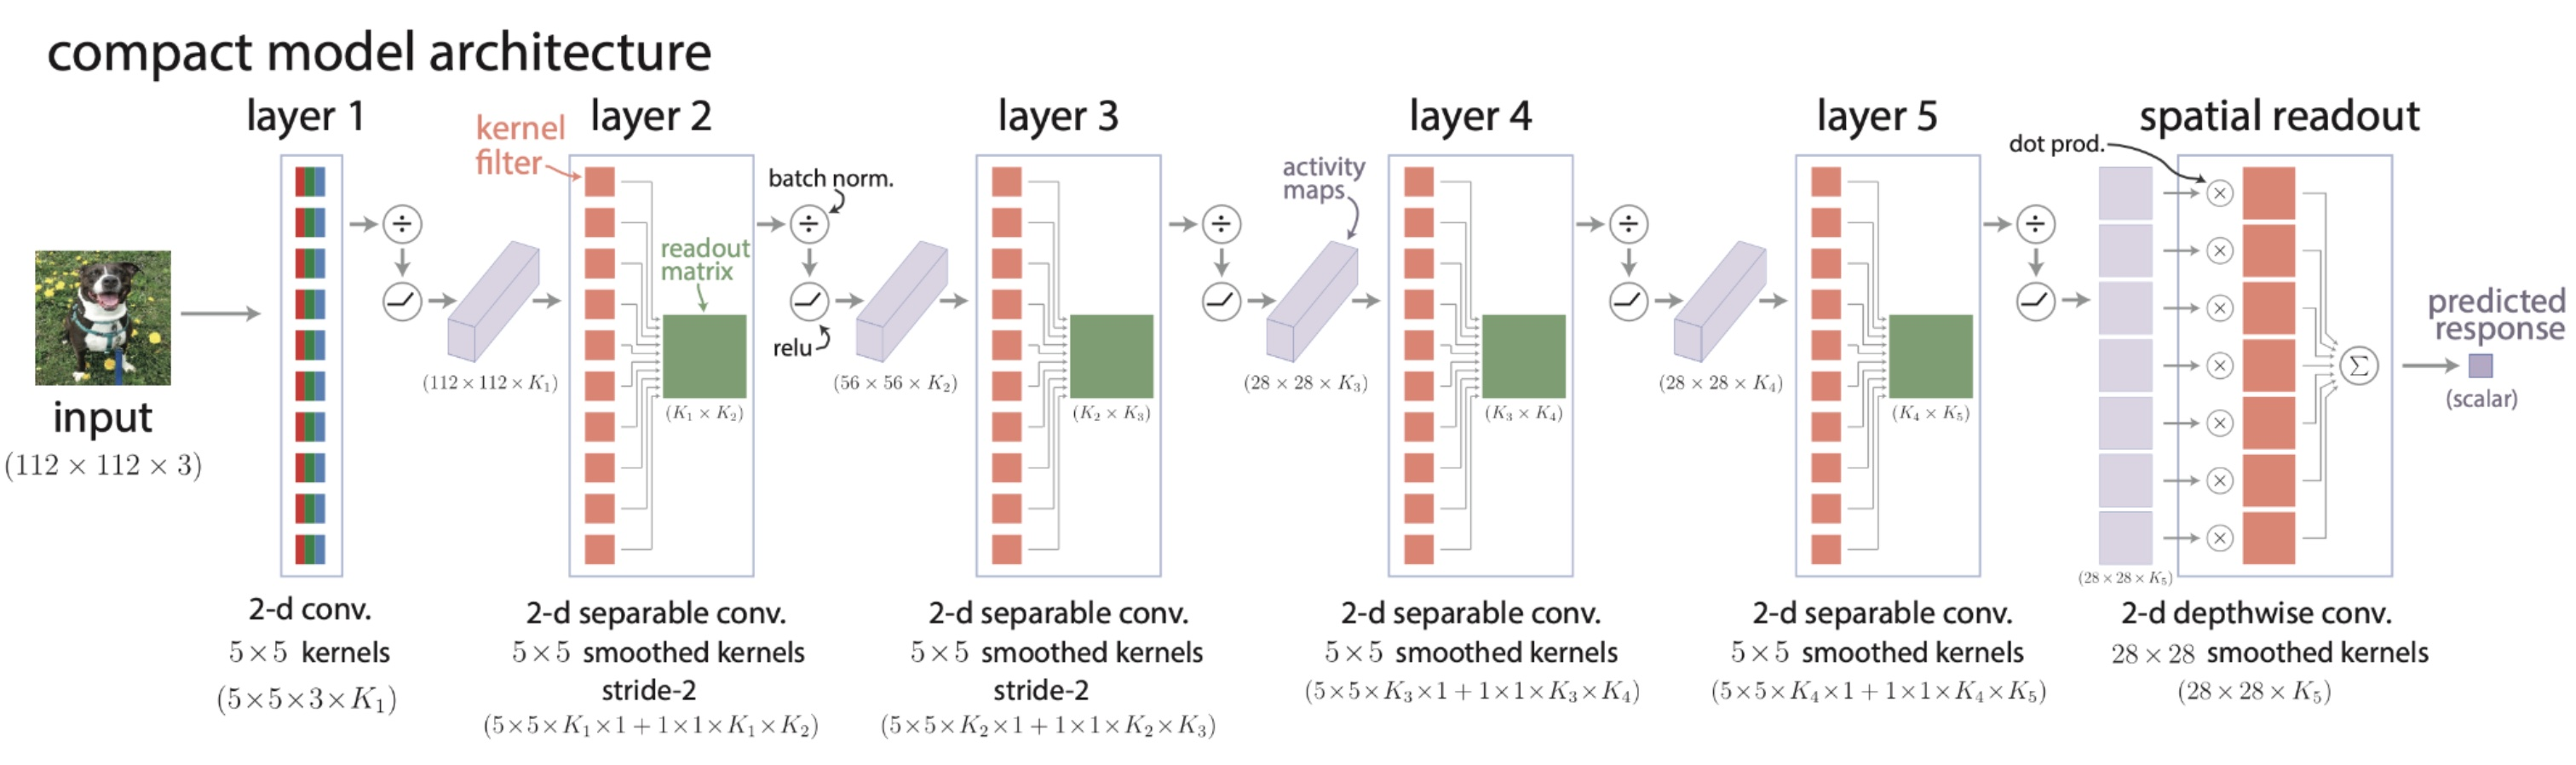
(~20 min)

Note: layer 1 in the figure is layer 0 in code (and so on).

In [ ]:
# Identify the kernel weights and plot them.
# This is not so easy!  You'll need to explore the
# model's architecture, and pull out the correct weights (4-d tensors!).
# I've added some helpful plotting normalization when you do
# get the correct weights.
# Hint: functions get_layer() and get_weights() are helpful.

if True: # prints out layer names and weight tensor shapes
  for layer in model.layers:
    print(layer.name)

    if 'layer' in layer.name or 'Beta' in layer.name:
      weights = model.get_layer(layer.name).get_weights()
      for W in weights:
        print(W.shape)

# plot kernel weights for layer 0 (hint: 5x5x3, so they are rgb)
weights = ??
num_filters = ??
f = plt.figure(figsize=(8,8))
f.suptitle('layer0_conv', fontsize=16)
for ifilter in range(num_filters):
  plt.subplot(10,10,ifilter+1)

  W = ??  # weights for ifilter
  W = W - np.min(W)
  W = W / np.max(W)

  plt.imshow(W)
  plt.axis('off')

# plot kernel weights for layers 0-4
for layer in model.layers:
  if 'conv' not in layer.name or layer.name == 'layer0_conv':
    continue  # not a convolutional layer

  weights = ??
  num_filters = ??

  f = plt.figure(figsize=(8,8))
  f.suptitle(layer.name, fontsize=16)
  for ifilter in range(num_filters):
    plt.subplot(10,10,ifilter+1)

    W = ?? # weights for filter ifilter
    v = np.quantile(np.abs(W), 0.95)

    plt.imshow(W, vmin=-v, vmax=v, cmap='PiYG_r')
    plt.axis('off')

# plot kernel weights for spatial readout layer
weights = ??  # dense weights
weights = np.reshape(weights, ??)  # reshape to be kernels/spatial readout filters

f = plt.figure(figsize=(15,15))
f.suptitle('spatial_readout_layer', fontsize=16)
num_filters = ??
for ifilter in range(num_filters):
  plt.subplot(10,10,ifilter+1)

  W = ??  # weights for filter ifilter
  v = np.quantile(np.abs(W), 0.95)

  plt.imshow(W, vmin=-v, vmax=v, cmap='PiYG_r')
  plt.axis('off')


# Find maximizing normal images

Pass in all 10k images into model in batches, keeping track of the top 16 images that maximize the output of the compact model.

(~15 min)

In [ ]:
## HELPER FUNCTIONS

def recenter_images(imgs_raw):
  # returns re-centered images
  #
  # INPUT:
  #   imgs_raw: (num_images, num_pixels, num_pixels, 3), raw images in RGB format
  # OUTPUT:
  #   imgs_recentered: (num_images, num_pixels, num_pixels, 3), re-centered images

  rgb_mean_pixels = [116.222, 109.270, 100.381]
  imgs = np.copy(imgs_raw)

  for ichannel in range(3):
    imgs[:,:,:,ichannel] -= rgb_mean_pixels[ichannel]
  return imgs


def get_batch_of_images(ibatch, batch_size, archive):
  # INPUT:
  #   ibatch: (int), indexes a batch of the images
  #   batch_size: (int), size of batch; note: 10k / batch_size --> last ibatch
  #   archive: (ZipFile), zipped memory of images
  # OUTPUT:
  #   imgs_cand: (batch_size, num_pixels, num_pixels, 3), images for this batch

  num_pixels = 112  # pre-defined for compact model

  imgs_cand = np.zeros((batch_size, num_pixels,num_pixels,3))
  istart = ibatch * batch_size
  for iimg in range(batch_size):
    ind = istart + iimg
    img_tag = 'images_5k/{:06d}.jpg'.format(istart + iimg)

    img = tf.keras.utils.load_img(BytesIO(archive.read(img_tag)), target_size=(num_pixels,num_pixels))
    img = tf.keras.utils.img_to_array(img)  # reads image in PIL format, then converts to numpy array
      # (num_pixels, num_pixels, 3)

    imgs_cand[iimg] = img

  return imgs_cand

In [ ]:
## MAIN SCRIPT

# NOTE: You may want to change your Colab runtime to include a GPU:
#  Go to toolbar, "Runtime" --> "Change runtime type" -->
#      "Hardware accelerator" --> GPU.

# run through batches of images, keeping track of largest responses
# HINT: Modify these values to debug/run faster in a CPU session.
#    When you think you're ready, run in a GPU session.
num_images = 5000  # total number of images
batch_size = 100  # number of candidate images per batch (can't pass all 5k into DNN at once)
num_batches = np.floor(num_images / batch_size).astype('int')  # num batches for 5k images
num_max_images = 16  # seeking the top 16 images

imgs_max = np.zeros((num_max_images,112,112,3))
responses_max = np.zeros((num_max_images,))
for ibatch in range(num_batches):
  print('batch {:d}'.format(ibatch))

  # FILL IN!
  # - get candidate images (HINT: use get_batch_of_images())
  # - preprocess images with recentering (see helper funcs)
  # - get responses to candidate images (HINT: use model.predict())
  # - keep track of top 16 images/responses
  # output: imgs_max (16, num_pixels, num_pixels, 3)

# plot images
f = plt.figure(figsize=(8,8))
for iimg in range(num_max_images):
  plt.subplot(4,4,iimg+1)
  plt.imshow(imgs_max[iimg].astype('uint8'))
  plt.axis('off')
  plt.title('r={:0.1f}'.format(responses_max[iimg]/0.1))  # normalize by 0.1 to convert to spikes/sec


# Grid search: Brute forcing it

- Start with image with white background
- Add the black 4x4 square that increases the model's response the most
- Keep adding these black squares in a greedy manner until the whole image is black

to do:
- plot images as they evolve
- plot responses vs. iterations

(~30 min)

In [ ]:

# NOTE: You may want to change your Colab runtime to include a GPU:
#  Go to toolbar, "Runtime" --> "Change runtime type" -->
#      "Hardware accelerator" --> GPU.

# start with white image
num_patches = 28
img_base = 255 * np.ones((112,112,3))  # starting image is all white
response_base = np.squeeze(model.predict(recenter_images(img_base[np.newaxis,:,:,:])))

# plot the first base image
f = plt.figure(figsize=(15,15))
ipanel = 1
plt.subplot(10,10,ipanel)
plt.imshow(img_base.astype('uint8'))
plt.axis('off')
plt.title('r={:0.1f}'.format(response_base/0.1))

num_iters = num_patches * num_patches  # reduce this for speed/checking
num_cand_images_per_iter = num_patches * num_patches  # reduce this for speed/checking

# keep track of optimized images
responses_grid = []
responses_grid.append(response_base)

# keep track of remaining candidate squares to change from white to black
# locs_cand[i,j] will be 1 if pixel patch is still white, otherwise 0 (black)
#  locs_cand[i,j] corresponds to img[i:i+4,j:j+4,:]

locs_cand = np.ones((num_patches,num_patches))   # initialized to all white

# now iteratively keep adding black squares
for iiter in range(num_iters):
  print('iter {:d}'.format(iiter))

  # FILL IN!
  # get candidate images from base image
  # Note: You could only sample num_images_per_iter images each iteration
  #        to avoid large batches of images, to reduce compute time.
  # - candidate images take the base image and add one black square
  #   in a previously white square (4 pixels x 4 pixels)
  # - get responses to all candidate images
  # - greedily choose next base image to maximize model's response
  #   hint: don't forget to remove the chosen candidate from locs_cand!
  # output:
  #   img_base --> new chosen base image that maximizes model's response
  #   response_base --> response of the new base image

  img_base = ??
  response_base = ??

  responses_grid.append(response_base)
  locs_cand[i,j] = 0  # this patch no longer needs to be evaluated

  # plot every once in a while
  if np.mod(iiter,8) == 7 or iiter == 784:
    # plt.subplot(10,10,ipanel)
    plt.imshow(img_base.astype('uint8'))
    plt.axis('off')
    print(response_base/0.1)
    plt.title('r={:0.2f}'.format(response_base/0.1))
    ipanel += 1

    plt.show()

# plot responses over iterations
f = plt.figure()
responses_grid = np.array(responses_grid)
plt.plot(responses_grid/0.1)
plt.xlabel('iteration number')
plt.ylabel('response')



# Find maximizing synthesized image via gradient ascent

- Typically, we take the derivative of the error with respect to a DNN's weights to update the weights.
- We can use the same idea, but take the derivative of the model's output with respect to the DNN's input (where weights remain fixed).

- Let's use gradient ascent to find the image that maximizes the model's response!

Plot:
- Image sequence from white noise to final image
- Response versus epoch number

**Warning!** Get ready for some funky images.

(~30 min)

In [ ]:
# HELPER FUNCTIONS

def recenter_images(imgs_raw):
  # returns re-centered images
  #
  # INPUT:
  #   imgs_raw: (num_images, num_pixels, num_pixels, 3), raw images in RGB format
  # OUTPUT:
  #   imgs_recentered: (num_images, num_pixels, num_pixels, 3), re-centered images

  rgb_mean_pixels = [116.222, 109.270, 100.381]
  imgs = np.copy(imgs_raw)

  for ichannel in range(3):
    imgs[:,:,:,ichannel] -= rgb_mean_pixels[ichannel]

  return imgs


def set_images_to_raw(imgs_recentered):
  # takes re-centered images (for compact model) and transforms them to raw by adding back the RGB means
  #
  # INPUT:
  #	imgs_recentered: (num_images,112,112,3), re-centered images where 112 is the number of pixels
  #
  # OUTPUT:
  #	imgs_raw: (num_images,112,112,3), raw images with pixel intensities between 0 and 255

  rgb_mean_pixels = [116.222, 109.270, 100.381]
  imgs = np.copy(imgs_recentered)

  for ichannel in range(3):
    imgs[:,:,:,ichannel] += rgb_mean_pixels[ichannel]

  imgs = np.clip(imgs, a_min=0, a_max=255)

  return imgs


def set_up_gradient_function():
  # sets up loss and grad functions for specific neuron/filter index
  #
  # INPUT:
  #	ilayer, ifilter (same as optimize_synth_image)
  # OUTPUT:
  #	None.

  # loss = Kback.mean(model.output)
  # grad = Kback.gradients(loss, model.inputs[0])[0]
  # grad /= (Kback.sqrt(Kback.mean(Kback.square(grad))) + 1e-5)  # normalize the gradient
  # loss_func = Kback.function([model.inputs[0]], [loss])
  # grad_func = Kback.function([model.inputs[0]], [grad])

  loss = keras.backend.mean(model.output)
  grad = keras.backend.gradients(loss, model.inputs[0])[0]
  grad /= (keras.backend.sqrt(keras.backend.mean(keras.backend.square(grad))) + 1e-5)  # normalize the gradient
  loss_func = keras.backend.function([model.inputs[0]], [loss])
  grad_func = keras.backend.function([model.inputs[0]], [grad])

  return loss_func, grad_func

# loss = tf.reduce_mean(model.output)
# # ... for square and sqrt:
# grad /= (tf.sqrt(tf.reduce_mean(tf.square(grad))) + 1e-5)



def get_white_noise_image():
  # returns a white noise image
  #
  # INPUT:
  #	None.
  # OUTPUT:
  #	img: (1,112,112,3), white noise image (re-centered)

  img = np.random.uniform(size=(1,112,112,3)) * 50 + 128

  return recenter_images(img)


def clip_recentered_image(img_synth):
  # clips the new image to be within range of pixel intensity space (between 0 and 255, but needs to be recentered)
  #
  # INPUT:
  #	img_synth: (1,112,112,3), rgb array, re-centered
  # OUTPUT:
  #	img_synth: (1,112,112,3), rgb array, re-centered and clipped values between 0 and 255 (when not re-centered)

  rgb_pixel_means = np.array([116.222, 109.270, 100.381])  # computed from our large image dataset, 112x112

  upper_bounds = 255. - rgb_pixel_means
  lower_bounds = 0. - rgb_pixel_means

  for ichannel in range(3):
    img_synth[:,:,:,ichannel] = np.clip(img_synth[:,:,:,ichannel], lower_bounds[ichannel], upper_bounds[ichannel])

  return img_synth

In [ ]:
# MAIN SCRIPT

# Note: I've left out some tricky parts. Try to do it yourself and google anything that helps you!
# If you still can't get it, ask a friend.  If they also can't get it, ask me =)

import scipy.ndimage as ndimage

# hyperparameters of image synthesis
if True:
  num_epochs=501
  step_size=10.
  gaussian_filter_sigma=1.

# synthesize image
if True:
  img_synth = ?? # start with white noise image
  loss_func, grad_func = ??  # get loss_func + grad_func of model
      # HINT: see Helper Functions section above

  f = plt.figure(figsize=(15,15))
  ipanel = 1
  iepoch = 0
  while iepoch < num_epochs:
    grad_value = ??  # get gradient function value for the current img_synth using grad_func
         # (hint: you may need to google how to get this grad value; extra hint: what shape should grad_value be?)

    # smooth gradient  (hint: ndimage.gaussian_filter)
    #    (hint, hint: make sure you only smooth the pixel dimensions
    #       by passing a tuple to sigma argument in ndimage.gaussian_filter)
    grad_value = ??

    # update image with gradient with step size (i.e., gradient ascent)
    img_synth = ??

    # clip image (to ensure it remains between 0 and 255)
    img_synth = clip_recentered_image(img_synth)

    response = ?? # get response to img_synth; hint: you can use loss_func for this

    if np.mod(iepoch,5) == 0 and ipanel <= 100:
      # plt.subplot(10,10,ipanel)
      plt.imshow(set_images_to_raw(img_synth)[0].astype('uint8'))
      plt.axis('off')
      plt.title('r={:0.2f}'.format(response/0.1))
      ipanel += 1

      plt.show()

    iepoch += 1




## Great job!
Did you remember to switch your compact_model.h5 to your given compact_modelXX.h5?